In [19]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# using Prebuild sklearn

In [45]:
X, y = make_classification(
    n_samples=100,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_classes=2,
    flip_y=0.1,
    random_state=42
)

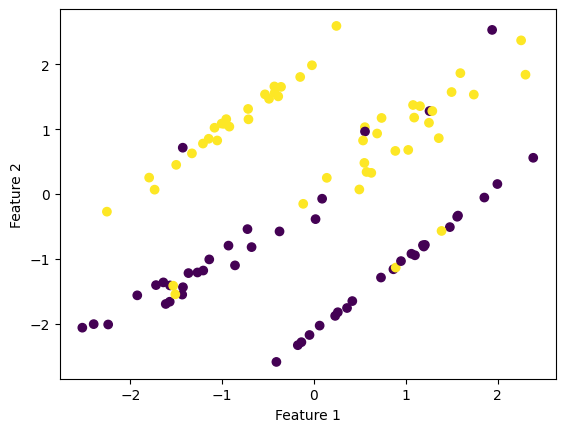

In [46]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [47]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42)

In [58]:
knn = KNeighborsClassifier(n_neighbors=3)

In [59]:
model=knn.fit(X_train,y_train)

In [60]:
y_pred=knn.predict(X_test)

In [61]:
print(accuracy_score(y_pred,y_test))

0.88


In [62]:
scores=[]
for i in range(1,16):
    knn = KNeighborsClassifier(n_neighbors=i)
    model=knn.fit(X_train,y_train)
    y_pred=knn.predict(X_test)
    scores.append(accuracy_score(y_pred,y_test))

In [63]:
scores

[0.64,
 0.68,
 0.88,
 0.88,
 0.88,
 0.88,
 0.88,
 0.88,
 0.88,
 0.84,
 0.84,
 0.84,
 0.84,
 0.8,
 0.84]

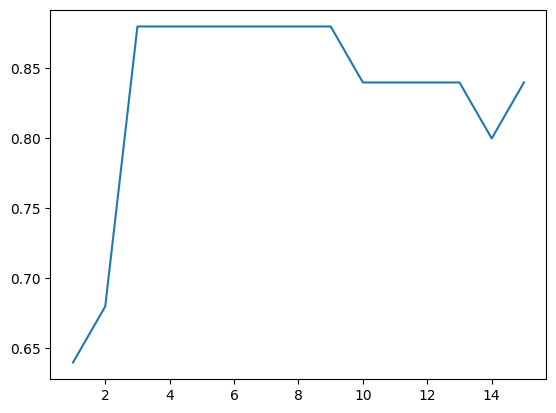

In [57]:
plt.plot(np.arange(1,16),scores)

# building from scratch

In [375]:
import numpy as np

class KNNScratch:

    # Initialize the KNN model
    def __init__(self, k):

        # Number of nearest neighbors to consider
        self.k_neighbors = k

        # These will store the training data
        self.X_train = None
        self.Y_train = None

    # Store the training data
    def fit(self, X_train, y_train):

        self.X_train = X_train
        self.y_train = y_train

    # Predict the class for test data
    def predict(self, X_test):

        # Store the test data
        self.X_test = X_test

        # This list will store predictions for all test points
        projection = []

        # Take one test point at a time
        for i in self.X_test:

            # Store distances between the current test point
            # and every training point
            distances = []

            # Go through every training point
            for j in self.X_train:

                # Calculate Euclidean distance
                # between test point 'i' and training point 'j'
                distance = np.linalg.norm(i - j)

                # Store the distance
                distances.append(distance)

            # Sort the distances and get the indices
            # of the K nearest training points
            nearest_indices = np.argsort(distances)[:self.k_neighbors]

            # Get the class labels of those K nearest points
            nearest_label = self.y_train[nearest_indices]

            # Find the unique class labels and
            # count how many times each class appears
            values, counts = np.unique(
                nearest_label,
                return_counts=True
            )

            # Find the index of the class with the highest count
            # and use that index to get the actual class label
            label = values[np.argmax(counts)]

            # Add the predicted label to our predictions list
            projection.append(label)

        # Return predictions for all test points
        return projection

In [376]:
model=KNNScratch(k=5)

In [377]:
model.fit(X_train,y_train)

In [378]:
model.predict(X_test)

[1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0]

## 

In [379]:
model=KNNScratch(k=3)

In [380]:
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print(accuracy_score(y_pred,y_test))

0.88


# decision Boundary

steps to plot Decision Boundary for Knn(Assuming 2 input cols)
1. Train the classifier on the training set.
2. Create a uniform grid(with the help of Numpy Meshgrids) of points that densely cover the region of input space containing the training set.
3. Classify each point on the grid. Store the results in an array A, where Aij contains the predicted class for the point at row i, column j on the grid.
4. Plot the array as an image, where each pixel corresponds to a grid point and its color represents the predicted class. The decision boundary can be seen as contours where the image changes color.
5. Finally print out the training data with their respective color on the same contour

## Step 2: Creating a Meshgrid

In [381]:
a=np.arange(start=X_train[:,0].min()-1, stop=X_train[:,0].max()+1, step=0.01)
b=np.arange(start=X_train[:,1].min()-1, stop=X_train[:,1].max()+1, step=0.01)


XX,YY=np.meshgrid(a,b)

In [387]:
print(XX.shape)
print(YY.shape)

(718, 692)
(718, 692)


In [410]:
YY.ravel().shape

(496856,)

In [408]:
XX.ravel().shape

(496856,)

In [399]:
np.array([XX.ravel(),YY.ravel()]).shape

(2, 496856)

## Step 3: Classifiying every point on the meshgrid

In [383]:
input_array=np.array([XX.ravel(),YY.ravel()]).T

labels=knn.predict(input_array)

## Step 4: Plotting the array as an image

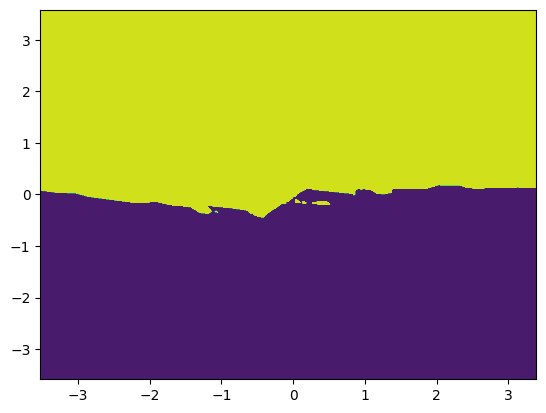

In [384]:
plt.contourf(XX,YY,labels.reshape(XX.shape))

## Step 5: Plotting all the training data on the plot

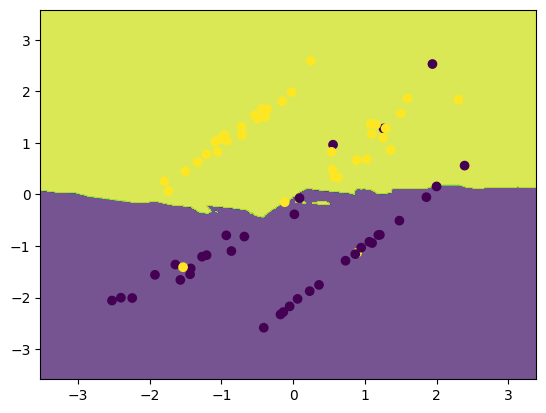

In [385]:
plt.contourf(XX,YY,labels.reshape(XX.shape), alpha=0.75)
plt.scatter(X_train[:,0],X_train[:,1], c=y_train)